# Paper Plots

## Setup

In [1]:
import rmatqmcpy 
import torch
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)

torch device = cpu
MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12


## WCEs

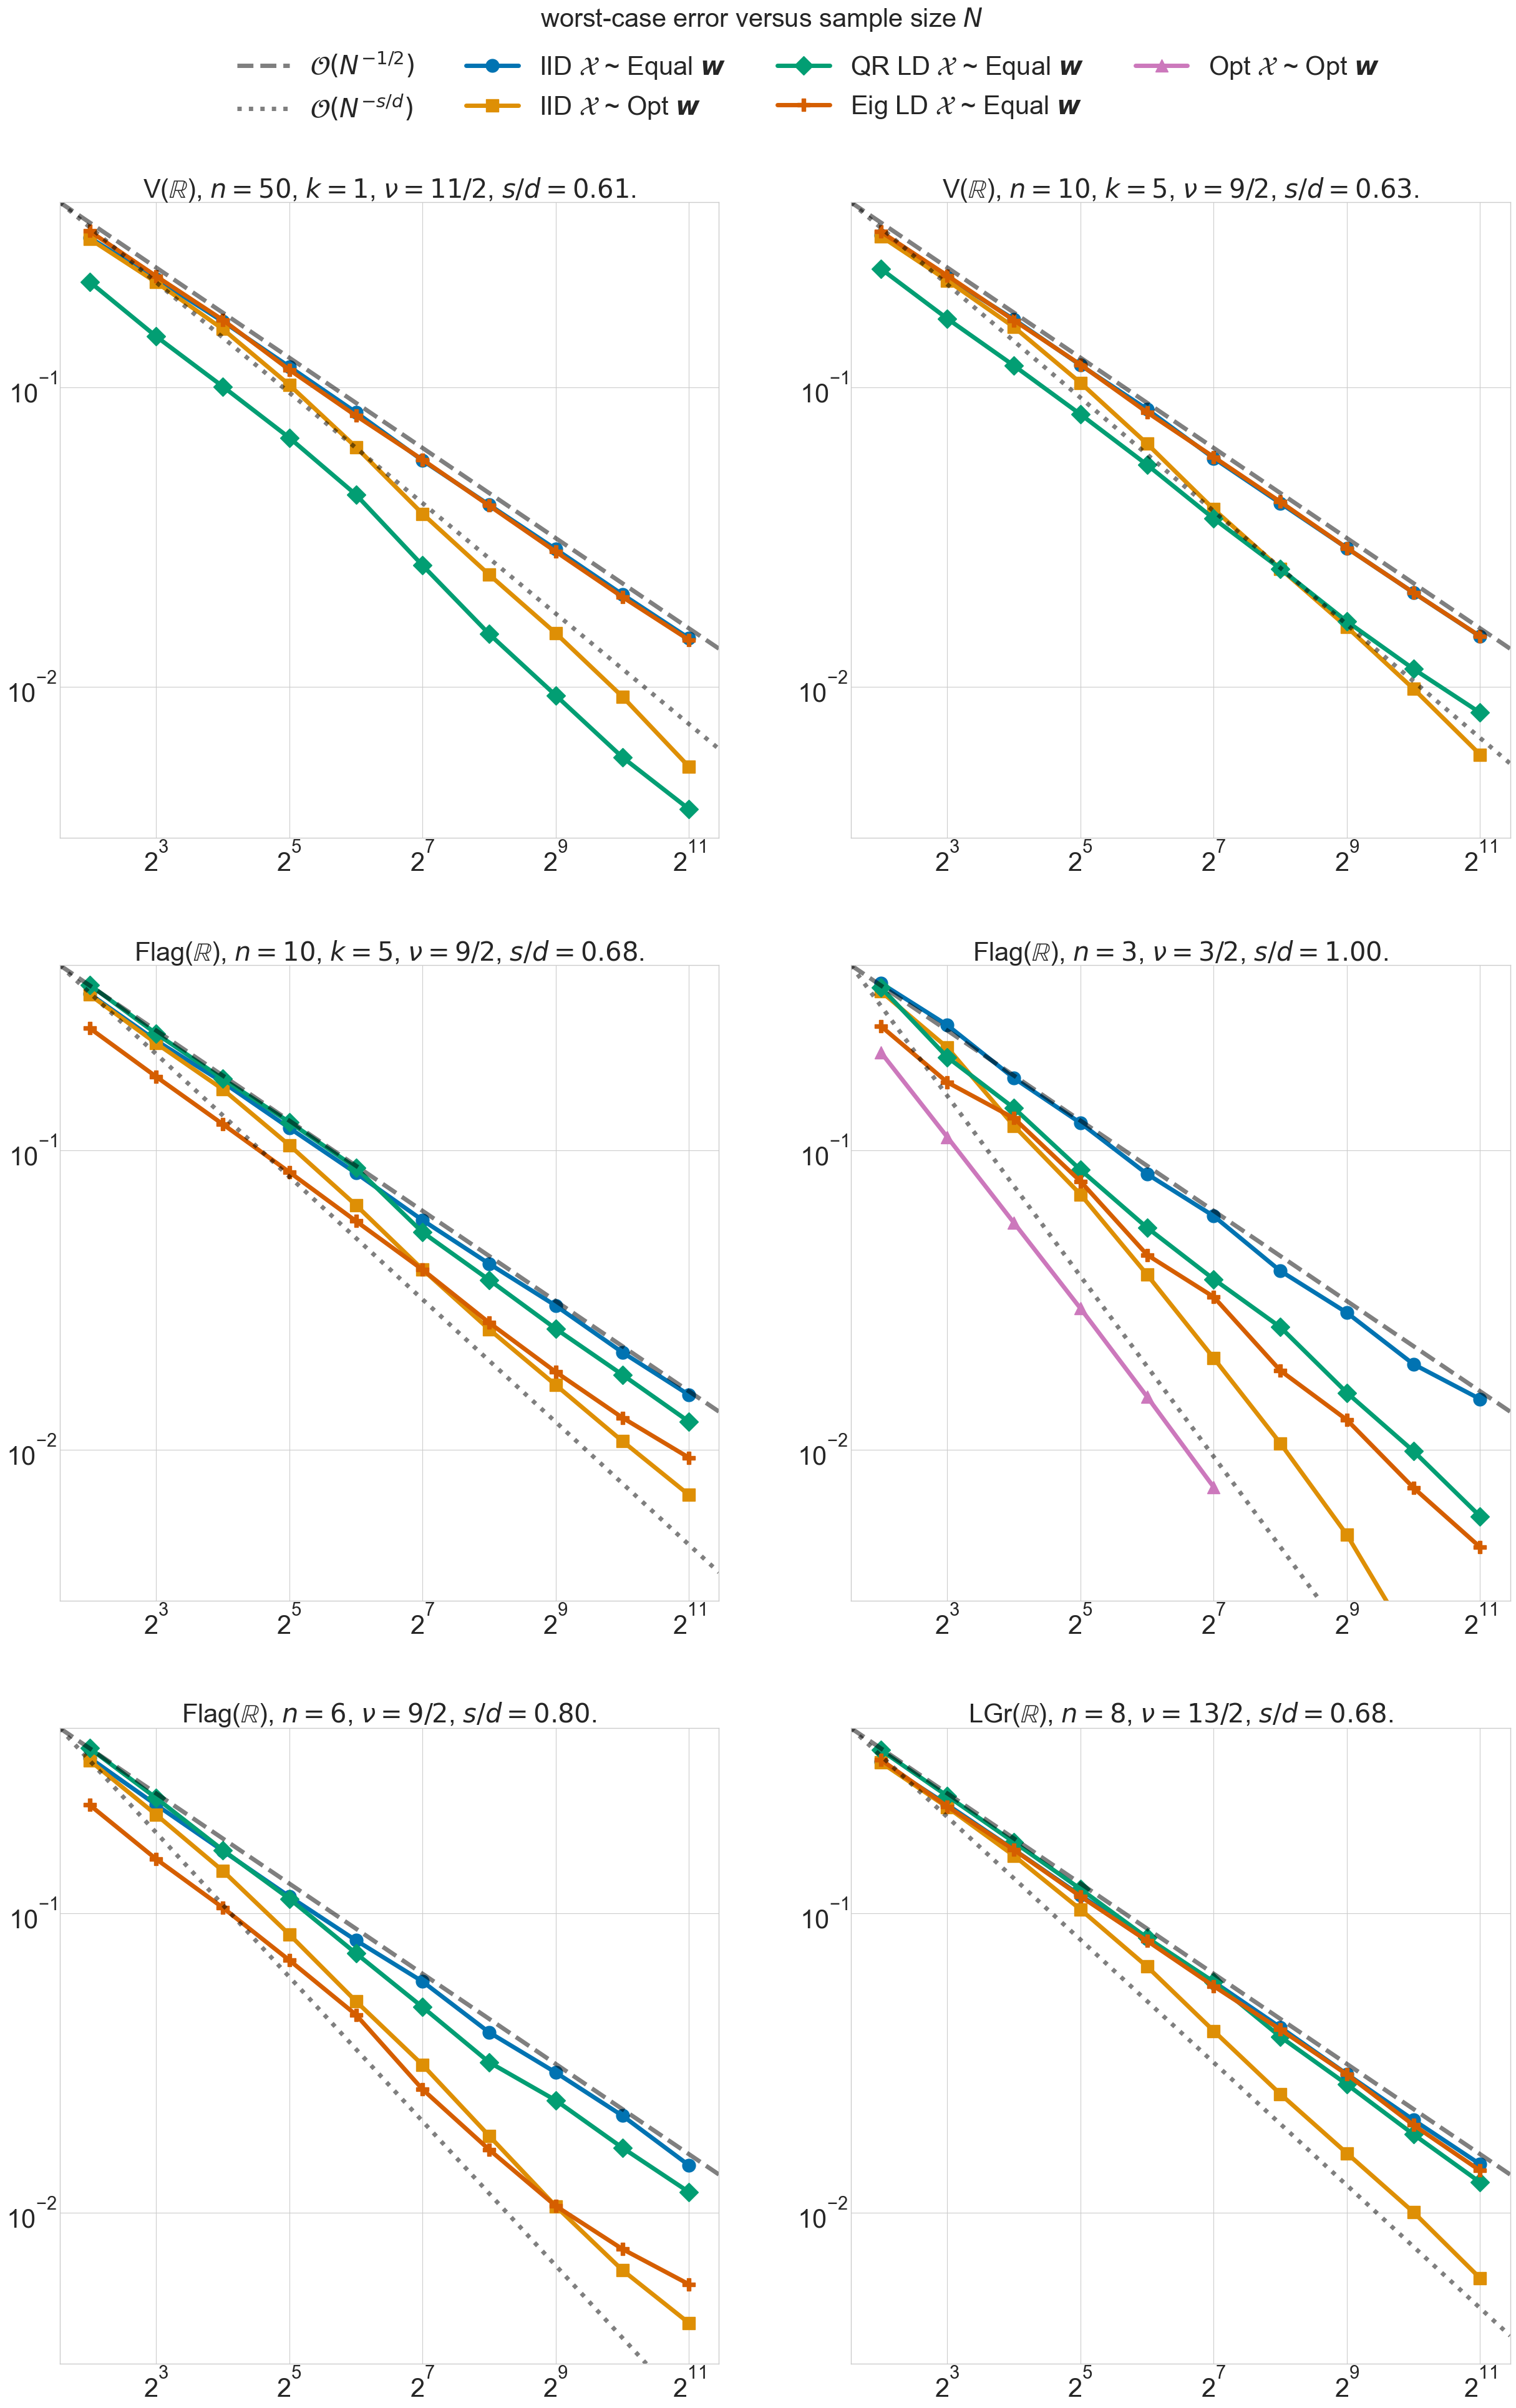

In [35]:
keyidx = 3 
datas = [
    torch.load("./out/data/Stiefel_R.n50.d49.nu5.5.pt"),
    torch.load("./out/data/Stiefel_R.n10.d35.nu4.5.pt"),
    torch.load("./out/data/Gr_R.n10.d25.nu4.5.pt"),
    torch.load("./out/data/flag_R.n3.d3.nu1.5.pt"),
    torch.load("./out/data/flag_R.n6.d15.nu4.5.pt"),
    torch.load("./out/data/LGr_R.n8.d36.nu6.5.pt"),
]
for data in datas:
    for i in range(len(data["names"])):
        assert data["names"][i]==datas[keyidx]["names"][i]
PW = MPLP["PW"]
nrows = 3
ncols = 2
assert len(datas)==(nrows*ncols)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(PW,PW/ncols*nrows),sharex=True,sharey=True)
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for i in range(nrows*ncols):
    ir,ic = i//ncols,i%ncols
    data = datas[i]
    s = data["s"]
    d = data["d"]
    for l,key in enumerate(data["names"]):
        ax[ir,ic].plot(data["N"],data["wces"][l].mean(-1),color=MPLP["COLORS"][l],marker=MPLP["MARKERS"][l],label=key if i==keyidx else None)
    ax[ir,ic].set_yscale("log",base=10)
    ax[ir,ic].set_xscale("log",base=2)
    # xmin,xmax = [N[0],N[-1]]
    xmin,xmax = ax[ir,ic].get_xlim()
    ymin,ymax = ax[ir,ic].get_ylim()
    ax[ir,ic].xaxis.set_tick_params(labelbottom=True)
    ax[ir,ic].yaxis.set_tick_params(labelleft=True)
    ax[ir,ic].set_xlim([xmin,xmax])
    ax[ir,ic].set_ylim([ymin,ymax])
    # ax[ir,ic].axline([xmax,ymin],[2*xmax,2**(-1/2)*ymin],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-1/2})$" if i==keyidx else None,linestyle="dashed")
    # ax[ir,ic].axline([xmax,ymin],[2*xmax,2**(-s/d)*ymin],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-s/d})$" if i==keyidx else None,linestyle="dotted")
    ax[ir,ic].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-1/2})$" if i==keyidx else None,linestyle="dashed")
    ax[ir,ic].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-s/d})$" if i==keyidx else None,linestyle="dotted")
    # ax[ir,ic].plot(N,ymax/(xmin**(-s/d)*torch.log(xmin)**(s/d))*N**(-s/d)*torch.log(N)**(s/d),color="k",alpha=0.5,linestyle="dashdot",label=r"$\mathcal{O}(N^{-s/d} \log(N)^{s/d})$" if i==keyidx else NOne)
    assert s==np.inf or s%1 in [0,1/2]
    if s==np.inf:
        s_str = r"\infty"
    elif s%1==0:
        s_str = r"%d"%s 
    elif s%1==1/2:
        s_str = r"%d/2"%(2*s)
    if data["manifold_type"]=="Stiefel":
        manifold_name = "V"
    elif data["manifold_type"]=="flag":
        manifold_name = "Flag"
    elif data["manifold_type"]=="Gr":
        manifold_name = "Flag"
    elif data["manifold_type"]=="LGr":
        manifold_name = "LGr"
    else: raise Exception("invalid data['manifold_type'] = %s"%data['manifold_type'])
    title = "" 
    title += r"%s($\mathbb{%s}$)"%(manifold_name,data["field"])
    title += r", $n=%d$"%data["n"]
    if data["manifold_type"] in ["Stiefel","Gr"]:
        title += r", $k=%d$"%data["k"]
    title += r", %s"%data["nu_str"]
    if False:
        title += r", $s = %s$"%s_str
        title += r", $d=%d$"%d
    title += r", $s/d = %.2f$"%(s/d)
    title += "."
    ax[ir,ic].set_title(title)
    # ax[ir,ic].set_xlabel(r"$N$")
    # ax[ir,0].set_ylabel("worst-case error")
handles,labels = ax[keyidx//ncols,keyidx%ncols].get_legend_handles_labels()
fig.legend(
    [handles[-2],handles[-1]]+[handles[i] for i in range(len(handles)-2)],
    [labels[-2],labels[-1]]+[labels[i] for i in range(len(labels)-2)],
    frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.525,.9))
fig.suptitle(r"worst-case error versus sample size $N$",y=.95,fontsize=MPLP["FS"])
# fig.tight_layout()
fig.savefig("./out/paper.fig.WCE.pdf",bbox_inches="tight",transparent=True)

## Intrinsic Volumes

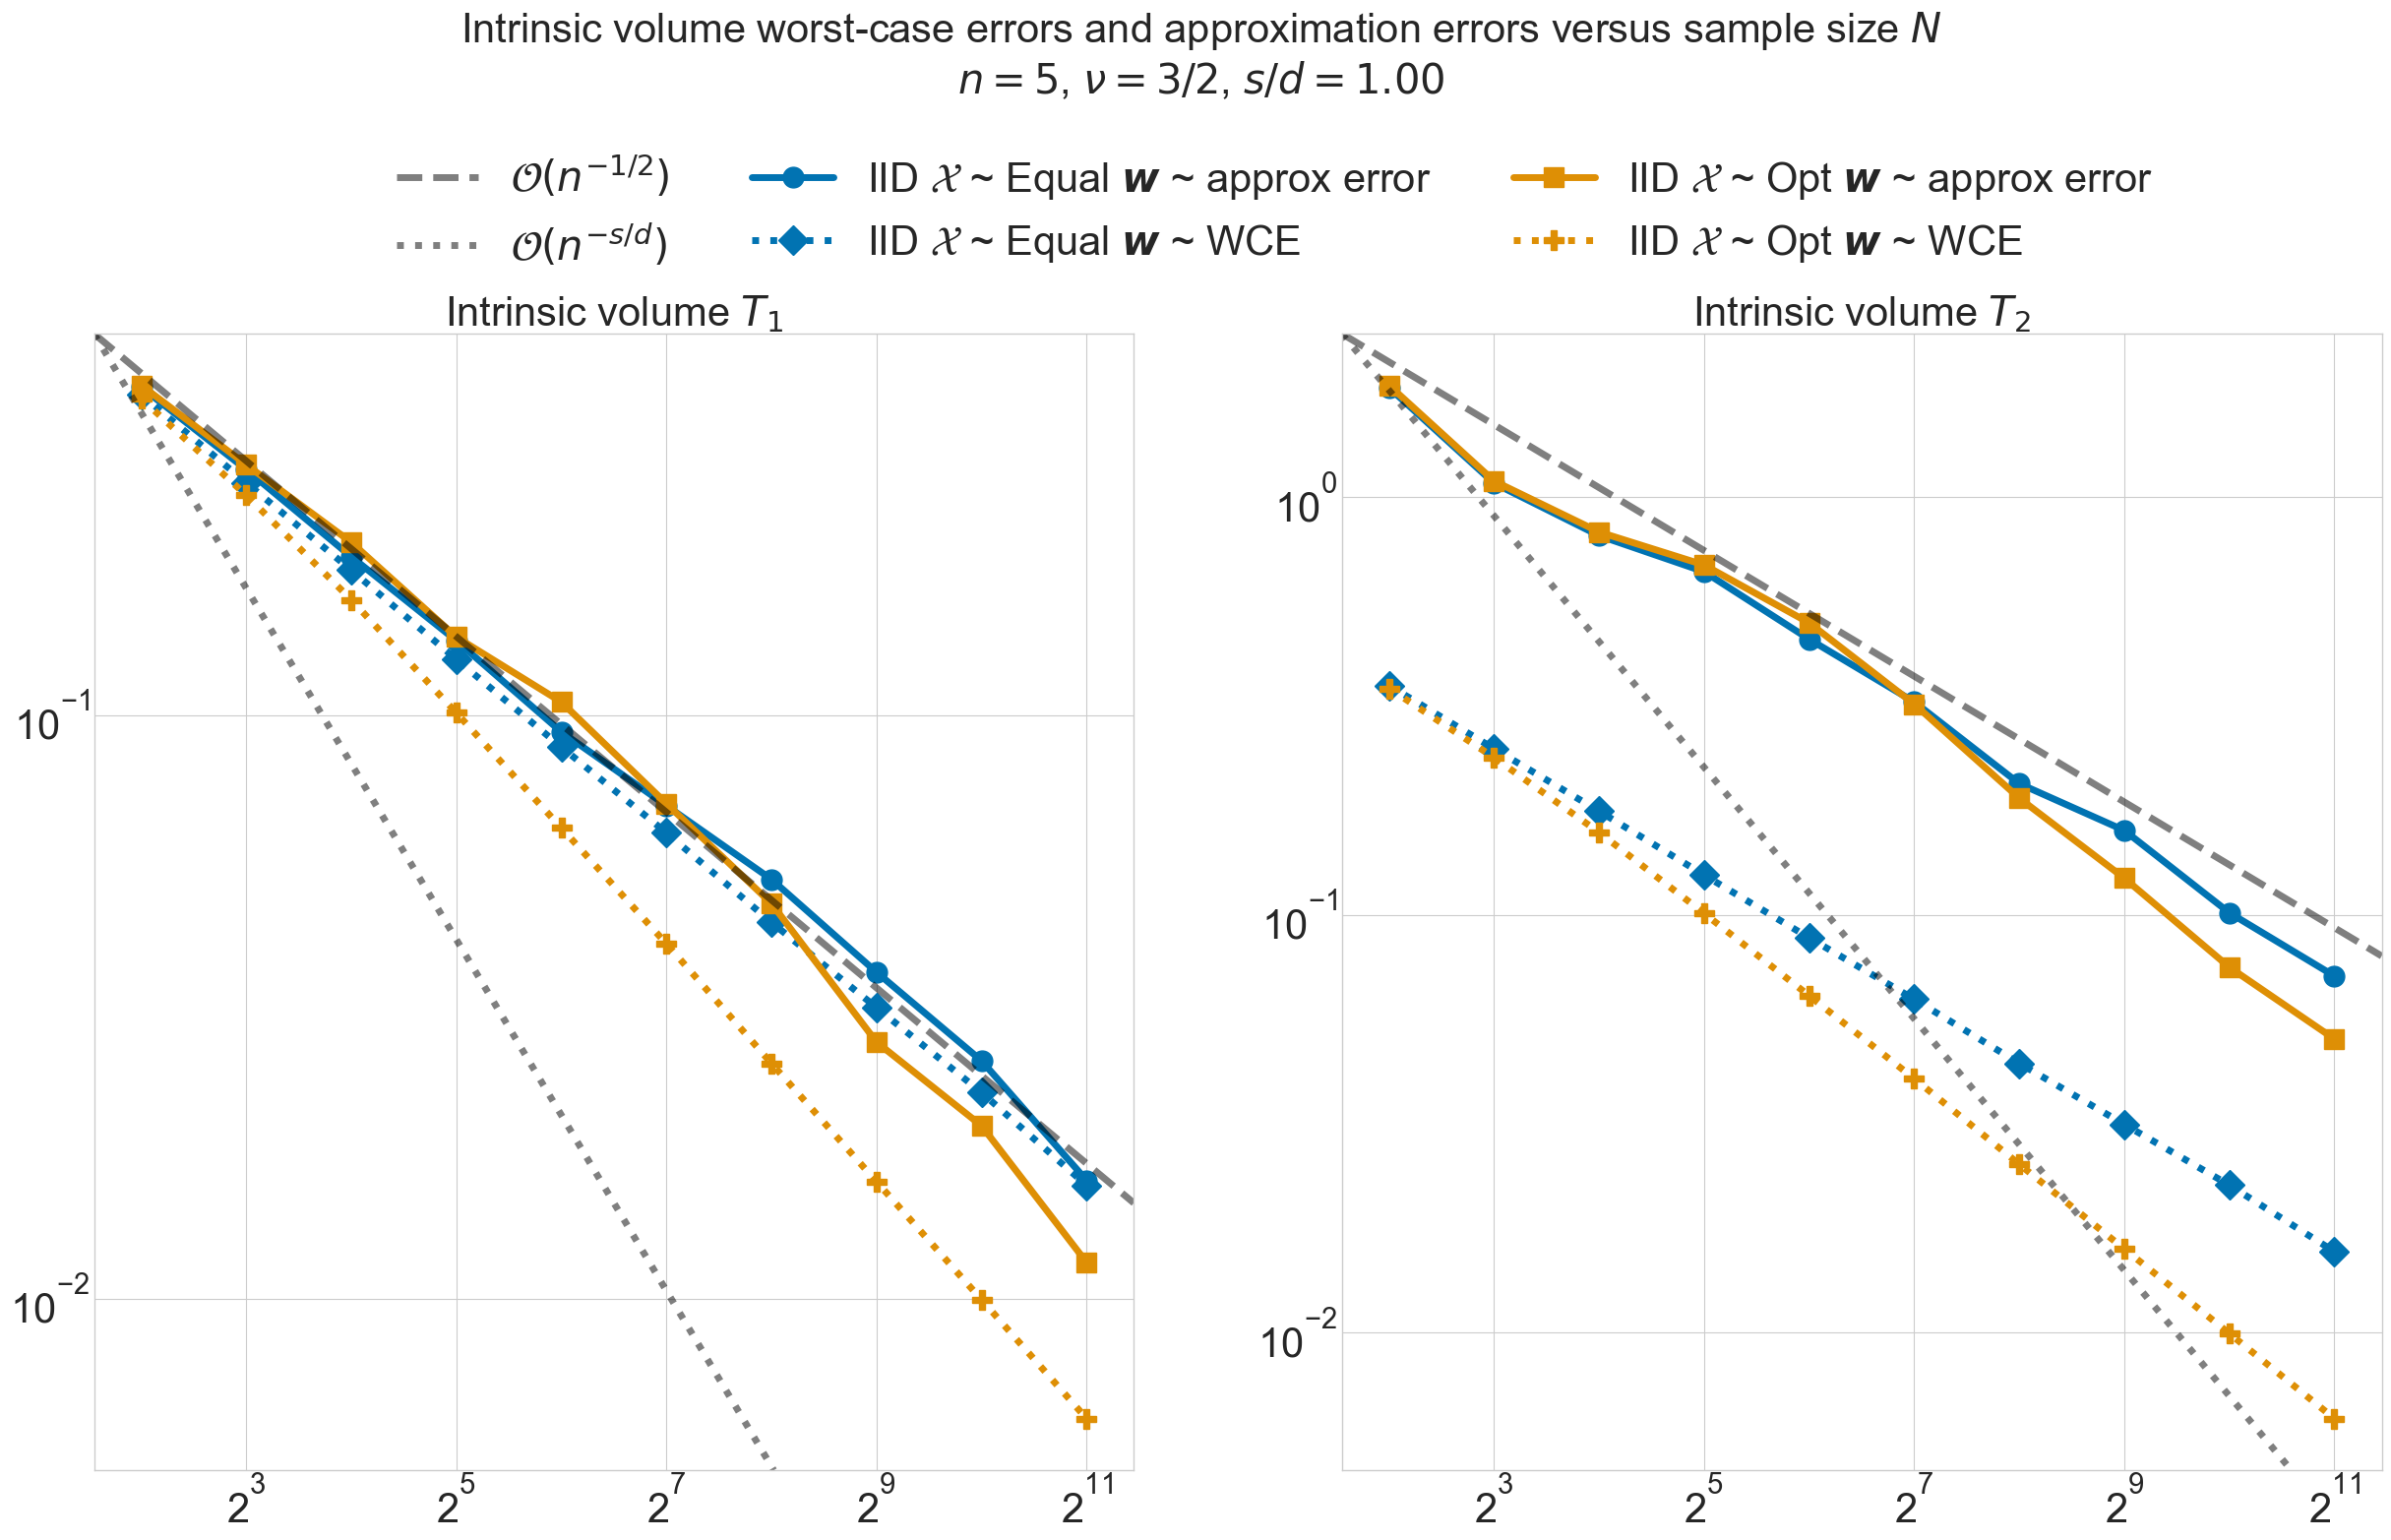

In [ ]:
# data = torch.load("./out/data/IV.n3.d3.nu1.5.pt")
data = torch.load("./out/data/IV.n5.d10.nu1.5.pt")
PW = MPLP["PW"]
errors_mean = data["errors"].mean(-2)
wces_means = data["wces"].mean(-1)
p = data["p"]
s = data["p"]
d = data["p"]
ncols = 2 
nrows = 1
assert p==(ncols*nrows)
fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(PW,PW/ncols*nrows),sharex=True,sharey=False)
ax = np.atleast_1d(ax).reshape((nrows,ncols))
for i,key in enumerate(data["names"]):
    for k in range(1,p+1):
        ir,ic = (k-1)//ncols,(k-1)%ncols
        ax[ir,ic].plot(data["N"],errors_mean[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key+" ~ approx error" if k==1 else None)
        ax[ir,ic].plot(data["N"],wces_means[i],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i+len(data["names"])],label=key+ " ~ WCE" if k==1 else None,linestyle="dotted")
for k in range(1,p+1):
    ir,ic = (k-1)//ncols,(k-1)%ncols
    ax[ir,ic].set_xscale("log",base=2)
    ax[ir,ic].set_yscale("log",base=10)
    # ax[ir,ic].set_xlabel(r"$N$")
    ax[ir,ic].set_title(r"Intrinsic volume $T_{%d}$"%k)
    xmin,xmax = ax[ir,ic].get_xlim()
    ymin,ymax = ax[ir,ic].get_ylim()
    ax[ir,ic].xaxis.set_tick_params(labelbottom=True)
    ax[ir,ic].yaxis.set_tick_params(labelleft=True)
    ax[ir,ic].set_xlim([xmin,xmax])
    ax[ir,ic].set_ylim([ymin,ymax])
    ax[ir,ic].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,linestyle="dashed",label=r"$\mathcal{O}(n^{-1/2})$" if k==1 else None)
    ax[ir,ic].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,linestyle="dotted",label=r"$\mathcal{O}(n^{-s/d})$" if k==1 else None)
handles,labels = ax[0,0].get_legend_handles_labels()
fig.legend(
    [handles[-2],handles[-1]]+[handles[i] for i in range(len(handles)-2)],
    [labels[-2],labels[-1]]+[labels[i] for i in range(len(labels)-2)],
    frameon=False,ncols=3,loc="lower center",bbox_to_anchor=(.525,.9))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
title = "" 
title += r"Intrinsic volume worst-case errors and approximation errors versus sample size $N$"+"\n"
title += r"$n=%d$"%data["n"]
title += r", %s"%data["nu_str"]
if False:
    title += r", $s = %s$"%s_str
    title += r", $d=%d$"%d
title += r", $s/d = %.2f$"%(s/d)
fig.suptitle(title,y=1.1)
# fig.tight_layout()
fig.savefig("./out/paper.fig.IV.%s.n%d.pdf"%(data["body"],data["n"]),bbox_inches="tight")